# HOTEL REVENUE ANALYSIS — COLAB NOTEBOOK

In [20]:
"""
▶ วิธีใช้ใน Colab:
  1. Upload ไฟล์ hotel_merged_dataset.xlsx เข้า Colab ก่อน
     (ไฟล์นี้ merge hotel_Finished_dataset + dim_room_inventory แล้ว)
  2. รัน Cell นี้ครั้งเดียว แล้วค่อยรัน Cell ถัดๆ ไปตามลำดับ
"""

'\n▶ วิธีใช้ใน Colab:\n  1. Upload ไฟล์ hotel_merged_dataset.xlsx เข้า Colab ก่อน\n     (ไฟล์นี้ merge hotel_Finished_dataset + dim_room_inventory แล้ว)\n  2. รัน Cell นี้ครั้งเดียว แล้วค่อยรัน Cell ถัดๆ ไปตามลำดับ\n'

In [21]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import numpy as np

# ─────────────────────────────────────────────────────────────
# โหลดไฟล์ที่ Merge hotel_Finished_dataset + dim_room_inventory แล้ว
# ─────────────────────────────────────────────────────────────
df = pd.read_excel("Hotel_Azure_Stay_Dataset_Finished.xlsx")

## CELL 1 : Hypothesis 1 — ขาย Promo มากเกินไปในวัน High Demand


1. 📊 กราฟ: Grouped Bar Chart — สัดส่วน Rack Rate vs Non-Rack Rate
          แยกตามวันในสัปดาห์ (เรียงจาก Mon → Sun)


2. 🔍 กราฟบอกอะไรกับเรา:
  • เปรียบเทียบสัดส่วนการขาย Rack Rate และ Non-Rack Rate
    ในแต่ละวันของสัปดาห์
  • วันศุกร์–เสาร์ (High Demand) ควรมีสัดส่วน Rack Rate สูงกว่าวันอื่น
    แต่ถ้ายังมี Non-Rack Rate ~30% แสดงว่าโรงแรมปล่อยโปรโมชัน
    มากเกินความจำเป็นในช่วงที่ควรเก็บราคาเต็ม


3. 💡 ทำไมใช้กราฟนี้:
  Grouped Bar เหมาะสมที่สุดสำหรับการเปรียบเทียบ 2 หมวดหมู่
  (Rack vs Non-Rack) ข้าม 7 วัน — ทำให้เห็นความแตกต่างของแต่ละวัน
  ได้ในมุมมองเดียว สื่อสารได้ชัดเจนกว่า Pie Chart หรือ Stacked Bar


4. 🗣️ วิธีพูดอธิบายแบบโปร:
  "กราฟนี้แสดง Rate Mix ในแต่ละวันของสัปดาห์
   จะเห็นว่าวันศุกร์และเสาร์ซึ่งเป็น Peak Demand มีสัดส่วน Non-Rack Rate
   ยังสูงถึงประมาณ X% ซึ่งหมายความว่าเรากำลังเสีย Revenue Opportunity
   เนื่องจาก Promo ที่ไม่จำเป็นในช่วงที่ Demand รองรับ Full Price ได้"


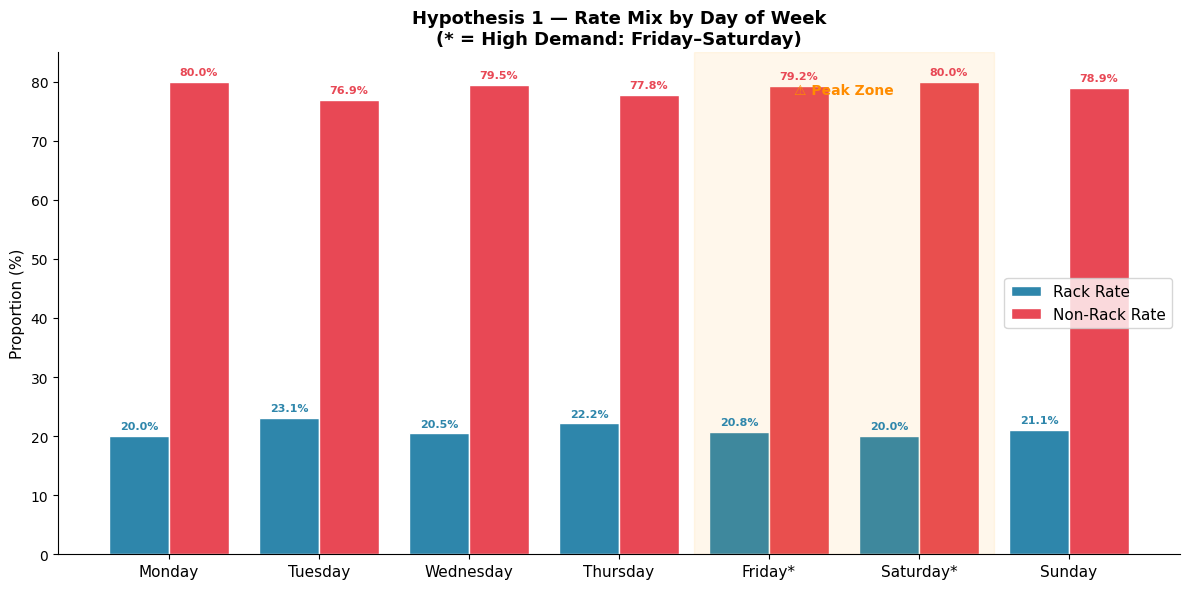

In [22]:
day_order = ["Monday", "Tuesday", "Wednesday", "Thursday", "Friday", "Saturday", "Sunday"]
day_th = {"Monday": "Monday", "Tuesday": "Tuesday", "Thursday": "Thursday",
          "Wednesday": "Wednesday", "Friday": "Friday*", "Saturday": "Saturday*", "Sunday": "Sunday"}

rate_mix = (
    df.groupby(["day_of_week", "is_rack"])
    .size()
    .reset_index(name="count")
)
rate_mix["day_of_week"] = pd.Categorical(rate_mix["day_of_week"], categories=day_order, ordered=True)
rate_mix = rate_mix.sort_values("day_of_week")
rate_pct = rate_mix.groupby(["day_of_week", "is_rack"], observed=False)["count"].sum().unstack(fill_value=0)
rate_pct = rate_pct.div(rate_pct.sum(axis=1), axis=0) * 100

fig, ax = plt.subplots(figsize=(12, 6))
x = np.arange(len(day_order))
w = 0.4
bars1 = ax.bar(x - w/2, rate_pct[1.0],  w, label="Rack Rate",     color="#2E86AB", edgecolor="white")
bars2 = ax.bar(x + w/2, rate_pct[0.0], w, label="Non-Rack Rate", color="#E84855", edgecolor="white")

for bar in bars1:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.8,
            f"{bar.get_height():.1f}%", ha="center", va="bottom", fontsize=8, color="#2E86AB", fontweight="bold")
for bar in bars2:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.8,
            f"{bar.get_height():.1f}%", ha="center", va="bottom", fontsize=8, color="#E84855", fontweight="bold")

ax.set_xticks(x)
ax.set_xticklabels([day_th[d] for d in day_order], fontsize=11)
ax.set_ylabel("Proportion (%)", fontsize=11)
ax.set_ylim(0, 85)
ax.set_title("Hypothesis 1 — Rate Mix by Day of Week\n(* = High Demand: Friday–Saturday)", fontsize=13, fontweight="bold")
ax.legend(fontsize=11)
ax.axvspan(3.5, 5.5, alpha=0.08, color="orange", label="Peak Zone")
ax.text(4.5, 78, "⚠ Peak Zone", ha="center", fontsize=10, color="darkorange", fontweight="bold")
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
plt.tight_layout()
plt.show()

## CELL 2 : Hypothesis 2 — OTA ดึงรายได้หายไป 8.7%


1. 📊 กราฟ: Grouped Bar Chart — Gross ADR vs Net ADR แต่ละ Channel
          พร้อมเส้นแสดง Commission Rate

2. 🔍 กราฟบอกอะไรกับเรา:
  • แสดง ADR ก่อน (Gross) และหลัง (Net) หัก Commission ทุก Channel
  • ช่อง OTA เช่น Booking.com / Expedia มักมี Gross ADR สูง
    แต่พอหัก Commission ~15-18% แล้ว Net ADR อาจต่ำกว่า Direct
  • ช่วยให้เห็น "ต้นทุนที่ซ่อนอยู่" ของแต่ละ Distribution Channel

3. 💡 ทำไมใช้กราฟนี้:
  Grouped Bar + Secondary Axis (Commission %) ทำให้เห็นทั้ง "มูลค่า"
  และ "ต้นทุน" ในกราฟเดียว — เหมาะสำหรับ Revenue Manager ที่ต้อง
  เปรียบเทียบ Channel Profitability อย่างรวดเร็ว

4. 🗣️ วิธีพูดอธิบายแบบโปร:
  "กราฟนี้แสดง Channel Economics — แท่งสีน้ำเงินคือ Gross ADR
   แท่งสีส้มคือ Net ADR หลังหัก Commission
   จะเห็นว่า Booking.com มี Gross ADR สูง แต่หลังหัก Commission ที่ X%
   Net ADR ต่ำกว่า Direct Web ซึ่งหมายความว่า Direct Channel
   ให้ผลตอบแทนที่แท้จริงสูงกว่า ควรลงทุน Drive Direct Booking"


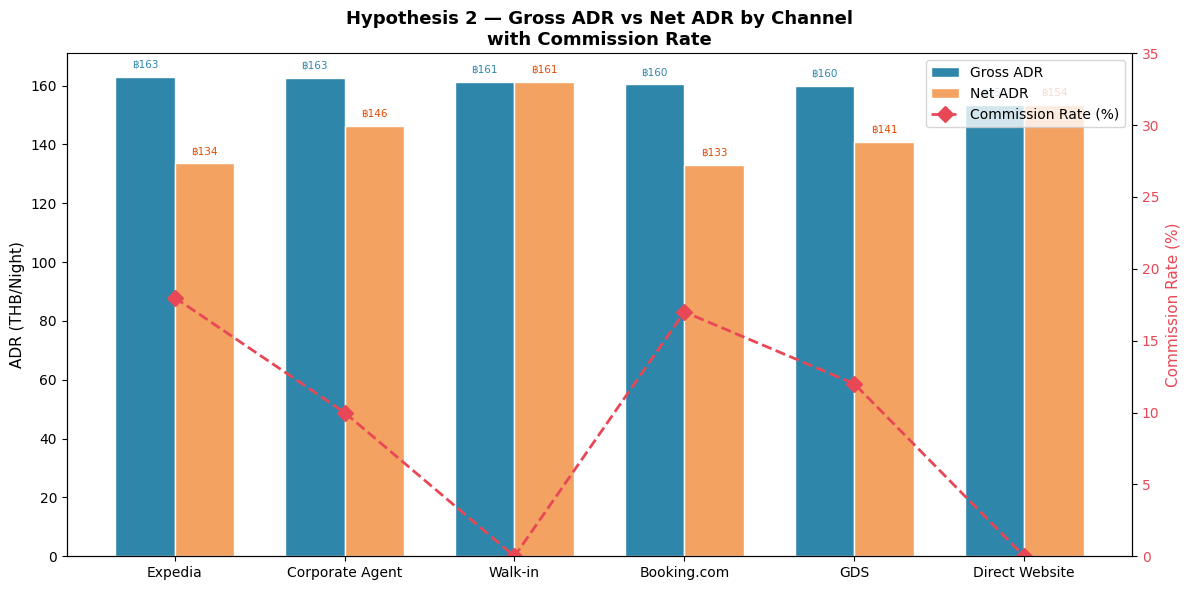

In [23]:
ch_adr = df.groupby("channel_name").agg(
    gross_ADR=("ADR", "mean"),
    net_ADR=("net_ADR", "mean"),
    commission=("commission_rate", "mean")
).reset_index().sort_values("gross_ADR", ascending=False)

fig, ax1 = plt.subplots(figsize=(12, 6))
ax2 = ax1.twinx()

x = np.arange(len(ch_adr))
w = 0.35
b1 = ax1.bar(x - w/2, ch_adr["gross_ADR"], w, label="Gross ADR",  color="#2E86AB", edgecolor="white")
b2 = ax1.bar(x + w/2, ch_adr["net_ADR"],   w, label="Net ADR",    color="#F4A261", edgecolor="white")
line = ax2.plot(x, ch_adr["commission"] * 100, "D--", color="#E84855",
                linewidth=2, markersize=8, label="Commission Rate (%)")

for bar in b1:
    ax1.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 3,
             f"฿{bar.get_height():,.0f}", ha="center", fontsize=7.5, color="#2E86AB")
for bar in b2:
    ax1.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 3,
             f"฿{bar.get_height():,.0f}", ha="center", fontsize=7.5, color="#E04A00")

ax1.set_xticks(x)
ax1.set_xticklabels(ch_adr["channel_name"], fontsize=10)
ax1.set_ylabel("ADR (THB/Night)", fontsize=11)
ax1.set_title("Hypothesis 2 — Gross ADR vs Net ADR by Channel\nwith Commission Rate", fontsize=13, fontweight="bold")
ax2.set_ylabel("Commission Rate (%)", fontsize=11, color="#E84855")
ax2.tick_params(axis="y", labelcolor="#E84855")
ax2.set_ylim(0, 35)

lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, fontsize=10, loc="upper right")
ax1.spines["top"].set_visible(False)
plt.tight_layout()
plt.show()

## CELL 3 : Hypothesis 3 — ไม่ได้ใช้ประโยชน์จาก Last-Minute Booking

1. 📊 กราฟ
Grouped Bar Chart — เปรียบ Rate Mix ระหว่าง Last-Minute (0–7 วัน) กับ Advance (31+ วัน) แยกตาม Rate Name ทั้ง 5 ประเภท
2. 🔍 กราฟบอกอะไรกับเรา
สิ่งที่น่าสนใจคือ Corporate Negotiated ซึ่งเป็น Rate ที่ให้ราคาต่ำที่สุด กลับถูกจองมากที่สุดในกลุ่ม Last-Minute (21.8%) ขณะที่ Advance อยู่แค่ 17.7% และ Rack Rate ของ Last-Minute ก็ต่ำกว่า Advance ด้วย (20.7% vs 21.4%)
พูดง่ายๆ คือคนจองกระชั้นได้ Rate ถูกกว่า ทำให้ ADR ต่ำกว่าคนจองล่วงหน้าถึง ฿12.7/คืน ทั้งที่ช่วงนี้โรงแรมควรขายราคาสูงกว่าได้

3. 💡 ทำไมใช้กราฟนี้
การตัดเหลือแค่ 2 กลุ่ม (Last-Minute vs Advance) ทำให้เปรียบเทียบได้ชัดโดยไม่ต้องกวาดตาหลายที่ ADR ของแต่ละกลุ่มอยู่ใน Legend เลย ทำให้เชื่อม "ผล" กับ "สาเหตุ" ได้ในกราฟเดียวโดยไม่ต้องอ่าน 2 กราฟพร้อมกัน

4. 🗣️ วิธีพูดอธิบายแบบโปร:กราฟนี้แสดง Rate Mix ของคนจองกระชั้น vs จองล่วงหน้า จะเห็นว่า Corporate Negotiated ซึ่งให้ ADR ต่ำสุด กลับมีสัดส่วนสูงที่สุดใน Last-Minute ที่ 21.8% ทำให้ ADR ต่ำกว่า Advance ถึง ฿12.7/คืน — ปัญหาไม่ใช่การลดราคา แต่เป็นการที่โรงแรมยังเปิด Corporate Rate ให้จองได้แม้ใกล้ Check-in"

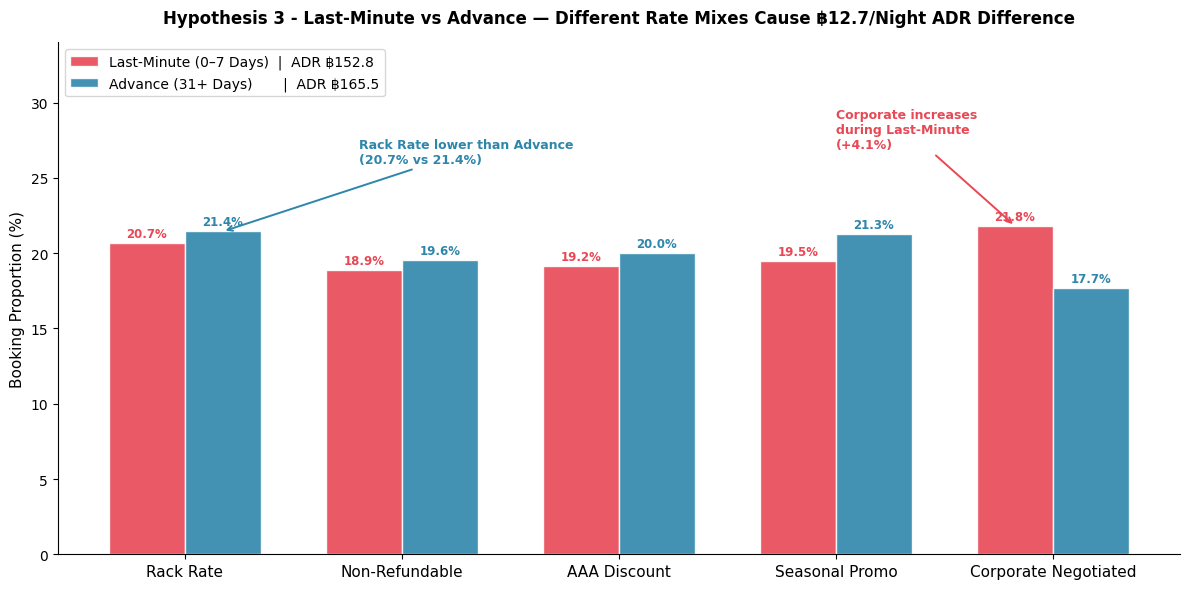

In [24]:
# ── Filter for Last-Minute vs Advance ──
two_bins = ["0-7 Days (Last-Minute)", "31+ Days (Advance)"]
df2 = df[df["lead_bin"].isin(two_bins)]

# Rate mix for these 2 groups only
rate_cols = ["Rack Rate", "Non-Refundable", "AAA Discount",
             "Seasonal Promo", "Corporate Negotiated"]

mix = (df2.groupby(["lead_bin","rate_name"])
          .size()
          .unstack(fill_value=0)
          .reindex(two_bins)[rate_cols])
mix_pct = mix.div(mix.sum(axis=1), axis=0) * 100

# ADR for each group
adr = df.groupby("lead_bin")["ADR"].mean().reindex(two_bins)

# ── Plot ──
x      = np.arange(len(rate_cols))
width  = 0.35
colors = {"0-7 Days (Last-Minute)": "#E84855",
          "31+ Days (Advance)":     "#2E86AB"}
labels = {"0-7 Days (Last-Minute)": f"Last-Minute (0–7 Days)  |  ADR ฿{adr.iloc[0]:.1f}",
          "31+ Days (Advance)":     f"Advance (31+ Days)       |  ADR ฿{adr.iloc[1]:.1f}"}

fig, ax = plt.subplots(figsize=(12, 6))

for i, bin_name in enumerate(two_bins):
    offset = (i - 0.5) * width
    bars = ax.bar(x + offset, mix_pct.loc[bin_name], width,
                  label=labels[bin_name],
                  color=colors[bin_name], edgecolor="white", alpha=0.9)
    for bar in bars:
        ax.text(bar.get_x() + bar.get_width()/2,
                bar.get_height() + 0.4,
                f"{bar.get_height():.1f}%",
                ha="center", fontsize=8.5,
                color=colors[bin_name], fontweight="bold")

# annotate 2 important points
# 1) Corporate increases during Last-Minute
corp_idx = rate_cols.index("Corporate Negotiated")
ax.annotate(
    "Corporate increases\nduring Last-Minute\n(+4.1%)",
    xy=(corp_idx - width/2, mix_pct.loc["0-7 Days (Last-Minute)", "Corporate Negotiated"]),
    xytext=(corp_idx - 1.0, 27),
    arrowprops=dict(arrowstyle="->", color="#E84855", lw=1.4),
    fontsize=9, color="#E84855", fontweight="bold"
)

# 2) Rack is lower than Advance
rack_idx = rate_cols.index("Rack Rate")
ax.annotate(
    "Rack Rate lower than Advance\n(20.7% vs 21.4%)",
    xy=(rack_idx + width/2, mix_pct.loc["31+ Days (Advance)", "Rack Rate"]),
    xytext=(rack_idx + 0.8, 26),
    arrowprops=dict(arrowstyle="->", color="#2E86AB", lw=1.4),
    fontsize=9, color="#2E86AB", fontweight="bold"
)

ax.set_xticks(x)
ax.set_xticklabels(rate_cols, fontsize=11)
ax.set_ylabel("Booking Proportion (%)", fontsize=11)
ax.set_ylim(0, 34)
ax.set_title(
    "Hypothesis 3 - Last-Minute vs Advance — Different Rate Mixes Cause ฿12.7/Night ADR Difference",
    fontsize=12, fontweight="bold", pad=14
)
ax.legend(fontsize=10, loc="upper left")
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

plt.tight_layout()
plt.show()

# Findings (Insights)

1. วันหยุดขายโปรโมชันเยอะเกินไป
วันศุกร์–เสาร์ที่ Demand สูงที่สุด กลับมี Non-Rack Rate สูงถึง 79.6% ต่างจากวันธรรมดา (78.6%) แทบไม่เลย แปลว่าโรงแรมยังเปิดส่วนลดเหมือนเดิมแม้ในวันที่คนอยากจองอยู่แล้ว ทำให้สูญเสีย ADR ที่ควรได้ไปโดยไม่จำเป็น ถ้าปิดโปรโมชันวัน Fri–Sat ได้ ADR จะเพิ่มขึ้นทันที ฿23/คืน
2. OTA นำคนมาจอง แต่รายได้จริงหายไป ฿175,424/ปี
OTA คิดเป็น 33.8% ของยอดจองทั้งหมด แต่เสีย Commission เฉลี่ย 17.5% ต่อการจอง ทำให้ Net ADR ของ OTA ต่ำกว่า Direct ถึง ฿24/คืน ยิ่งพึ่ง OTA มาก รายได้ที่หายไปยิ่งสะสม — OTA ช่วยเรื่อง Volume แต่แลกมาด้วย Margin ที่บางลงทุกปี
3. คนจองกระชั้นได้ราคาถูกกว่า — เพราะ Rate Mix ผิด ไม่ใช่เพราะโรงแรมลดราคาให้
Last-Minute booking (≤7 วัน) มี ADR ฿152.8 ต่ำกว่า Advance 31+ วัน (฿165.5) ถึง ฿12.7/คืน สาเหตุไม่ใช่การให้ส่วนลดพิเศษ แต่เป็นเพราะ Corporate Negotiated ยังเปิดให้จองได้อยู่ในช่วง Last-Minute และครองสัดส่วนสูงสุดที่ 21.8% ขณะที่ Rack Rate มีแค่ 20.7% — โรงแรมยังไม่ได้ใช้ประโยชน์จากช่วงที่ควร Capture Full Price ได้

# Recommendations

1. ปิดโปรโมชันวันศุกร์–เสาร์ + ดันสัดส่วน Rack Rate ขึ้น
เปิดขายเฉพาะราคาเต็ม (Rack) และ Non-Refundable วัน Fri–Sat ไม่ต้องลด AAA หรือ Seasonal Promo ในวันที่คนอยากจองอยู่แล้ว ควบคู่กับการลดการปล่อย Non-Rack Rate ในทุกวัน เป้าหมาย: ได้คืน ADR ฿23/คืน และ Non-Rack ลดจาก 78.9% → 72.0%
2. ดึงการจอง Direct แทน OTA ทำให้คนรู้ว่าจองตรงกับโรงแรมได้ราคาดีที่สุด แล้วลงทุนโฆษณาบน Google Hotel Ads เพื่อให้คนเห็นโรงแรมก่อนตัดสินใจจองผ่านช่องทางอื่น OTA เป้าหมาย Shift 10% ประหยัด Commission ได้ ฿17,500+/ปี
3. ปิด Corporate Negotiated และ Promo Rate เมื่อ Booking Window ≤7 วัน
เมื่อ Check-in ใกล้ถึง ให้เปิดจองได้เฉพาะ Rack Rate และ Non-Refundable เท่านั้น ป้องกันไม่ให้ Corporate Rate มาครอง Last-Minute เป้าหมาย Rack Rate ของ Last-Minute จาก 20.7% → 40%+ และ ADR จาก ฿152.8 → ฿165+
